## 6. Pressão arterial

### Objetivo

Esta seção tem como objetivo caracterizar as medidas de **pressão arterial sistólica e diastólica** dos participantes e investigar suas relações com outras informações disponíveis na base.

Inicialmente, são analisadas a distribuição das medidas, o número de leituras utilizadas e a presença de valores extremos. Em seguida, são investigadas a relação entre pressão sistólica e diastólica, as diferenças segundo o histórico informado de hipertensão e a associação entre idade e pressão sistólica.

As medidas utilizadas correspondem à média das leituras válidas disponíveis para cada participante. Como os dados do NHANES analisados são transversais, os resultados representam diferenças entre participantes avaliados no período estudado e não o acompanhamento da pressão arterial dos mesmos indivíduos ao longo do tempo.

Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display


sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Identidade visual do HealthSync
COR_PRINCIPAL = "#0E766D"
COR_SECUNDARIA = "#10B981"
COR_TERCIARIA = "#14B8A6"

COR_DESTAQUE = "#F28C82"
COR_NEUTRA = "#94A3B8"

# Cores consistentes para respostas binárias
COR_SIM = COR_PRINCIPAL
COR_NAO = COR_NEUTRA

plt.rcParams["figure.figsize"] = (10, 6)

plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

plt.rcParams["figure.dpi"] = 120

Abrindo o csv, e testando se carregou corretamente

In [3]:
CAMINHO_CORE = "../../dataset/healthsync_nhanes_2021_2023_core.csv"

df = pd.read_csv(CAMINHO_CORE)

display(df.head())

Dataset carregado com sucesso.
Participantes: 5283
Variáveis: 23


,id_participante,peso_estatistico_mec,peso_estatistico_entrevista,psu,estrato_amostral,idade,sexo,imc,pressao_sistolica,pressao_diastolica,...,glicose_jejum,colesterol_total,diabetes_informado,hipertensao_informada,hipertensao_2consultas,colesterol_alto_informado,medicamento_pressao,atv_moderada_min_semana,atv_vigorosa_min_semana,minutos_sedentarios_dia
0,130378.0,54.374.463.898,50.055.450.807,2.0,173.0,43.0,Homem,27.0,132.7,96.0,...,113.0,264.0,Nao,1.0,1.0,0.0,1.0,135.0,135.0,360.0
1,130379.0,34.084.721.548,29.087.450.605,2.0,173.0,66.0,Homem,33.5,117.0,78.7,...,99.0,214.0,Nao,1.0,1.0,0.0,1.0,180.0,135.0,480.0
2,130380.0,81.196.277.992,80.062.674.301,1.0,174.0,44.0,Mulher,29.7,109.0,78.3,...,156.0,187.0,Sim,0.0,NaN,1.0,NaN,20.0,0.0,240.0
3,130386.0,3.998.845.294,3.099.528.261,1.0,179.0,34.0,Homem,30.2,115.0,73.7,...,100.0,183.0,Nao,0.0,NaN,0.0,NaN,30.0,6.9,180.0
4,130387.0,2.077.625.485,19.896.970.559,1.0,181.0,68.0,Mulher,42.6,141.3,76.0,...,NaN,203.0,Nao,1.0,1.0,1.0,1.0,0.0,0.0,1200.0


### 6.1 Resumo das medidas

**Pergunta da análise:** quais são as principais características das distribuições da pressão sistólica e diastólica na amostra?

São utilizadas estatísticas descritivas para avaliar tendência central, dispersão e amplitude das duas medidas antes da análise gráfica de suas distribuições.

In [5]:
resumo_pressao = (
    df[
        [
            "pressao_sistolica",
            "pressao_diastolica"
        ]
    ]
    .describe()
    .T
    .round(2)
)

display(resumo_pressao)


,count,mean,std,min,25%,50%,75%,max
pressao_sistolica,5283.0,122.67,17.77,70.0,110.7,120.3,132.3,215.0
pressao_diastolica,5283.0,74.75,10.88,34.0,67.3,74.0,81.3,139.0


A pressão sistólica apresentou média de **122,67 mmHg** e mediana de **120,3 mmHg**, com metade dos participantes apresentando valores entre aproximadamente **110,7 e 132,3 mmHg**.

A pressão diastólica apresentou média de **74,75 mmHg** e mediana de **74,0 mmHg**, com metade das observações entre aproximadamente **67,3 e 81,3 mmHg**.

As medidas apresentaram amplitudes consideráveis, com valores entre **70 e 215 mmHg** para a pressão sistólica e entre **34 e 139 mmHg** para a pressão diastólica. A presença desses valores será investigada posteriormente, sem classificá-los automaticamente como erros.

### 6.2 Número de leituras válidas

As medidas de pressão utilizadas na base correspondem à média das leituras válidas disponíveis para cada participante. Por esse motivo, é importante verificar quantas medições contribuíram para o cálculo dessas médias.

Essa análise permite avaliar se a maioria dos participantes possui o mesmo número de leituras e identificar casos em que a média foi calculada a partir de menos observações.

In [6]:
print("Leituras válidas — Sistólica")
display(
    df["leituras_validas_sistolica"]
    .value_counts()
    .sort_index()
)

print("\nLeituras válidas — Diastólica")
display(
    df["leituras_validas_diastolica"]
    .value_counts()
    .sort_index()
)

Leituras válidas — Sistólica


leituras_validas_sistolica
1       4
2      14
3    5265
Name: count, dtype: int64


Leituras válidas — Diastólica


leituras_validas_diastolica
1       4
2      14
3    5265
Name: count, dtype: int64

Dos **5.283 participantes**, **5.265** possuem três leituras válidas de pressão sistólica e diastólica, enquanto **14** possuem duas leituras e apenas **4** possuem uma leitura válida.

Portanto, aproximadamente **99,7% da amostra possui três medições válidas**, indicando que as médias utilizadas representam, na grande maioria dos casos, o conjunto completo das três leituras disponíveis.

Os participantes com uma ou duas leituras foram mantidos na análise, pois a quantidade menor de medições, isoladamente, não constitui evidência suficiente para excluir esses registros.

### 6.3 Distribuição da pressão arterial

**Pergunta da análise:** como as medidas de pressão sistólica e diastólica estão distribuídas entre os participantes?

Os histogramas permitem visualizar a concentração, dispersão e formato das duas distribuições. As medidas são apresentadas separadamente, pois representam componentes distintos da pressão arterial e possuem escalas diferentes.

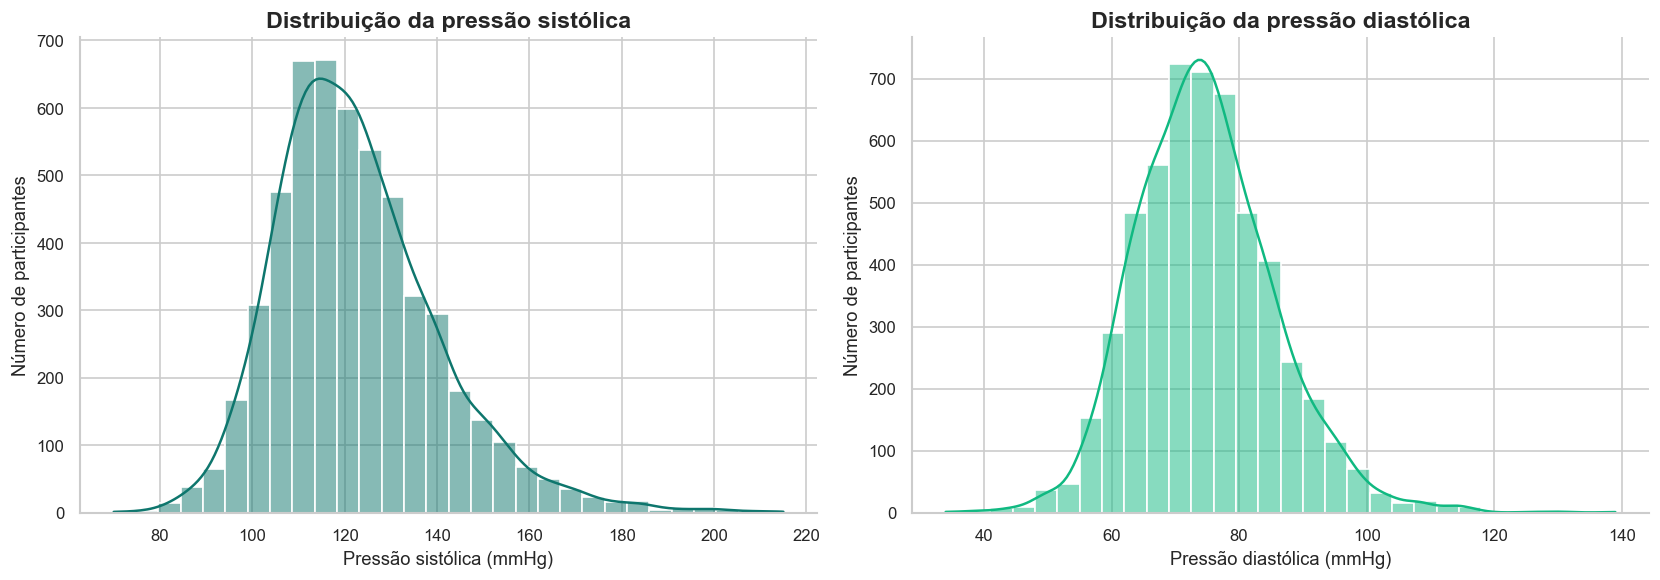

In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    data=df,
    x="pressao_sistolica",
    bins=30,
    kde=True,
    color=COR_PRINCIPAL,
    edgecolor="white",
    ax=axes[0]
)

axes[0].set_title(
    "Distribuição da pressão sistólica",
    weight="bold"
)

axes[0].set_xlabel(
    "Pressão sistólica (mmHg)"
)

axes[0].set_ylabel(
    "Número de participantes"
)


sns.histplot(
    data=df,
    x="pressao_diastolica",
    bins=30,
    kde=True,
    color=COR_SECUNDARIA,
    edgecolor="white",
    ax=axes[1]
)

axes[1].set_title(
    "Distribuição da pressão diastólica",
    weight="bold"
)

axes[1].set_xlabel(
    "Pressão diastólica (mmHg)"
)

axes[1].set_ylabel(
    "Número de participantes"
)

sns.despine()

plt.tight_layout()
plt.show()

As duas medidas apresentam maior concentração em torno de suas regiões centrais, acompanhada de menor frequência nas extremidades das distribuições.

A pressão sistólica apresenta maior dispersão, com desvio-padrão de **17,77 mmHg**, enquanto a pressão diastólica apresenta desvio-padrão de **10,88 mmHg**.

Também são observados valores afastados das regiões de maior concentração, especialmente na extremidade superior da pressão sistólica. Esses casos serão examinados com maior detalhe nas próximas análises.

### 6.4 Valores extremos

**Objetivo:** complementar a análise das distribuições e identificar observações mais afastadas das regiões centrais da pressão sistólica e diastólica.

Para facilitar a comparação, as duas medidas são apresentadas em um mesmo boxplot. A visualização permite observar medianas, intervalos interquartis e valores mais distantes da distribuição.

Assim como nas análises anteriores, observações identificadas visualmente como extremas não serão consideradas automaticamente erros de registro.

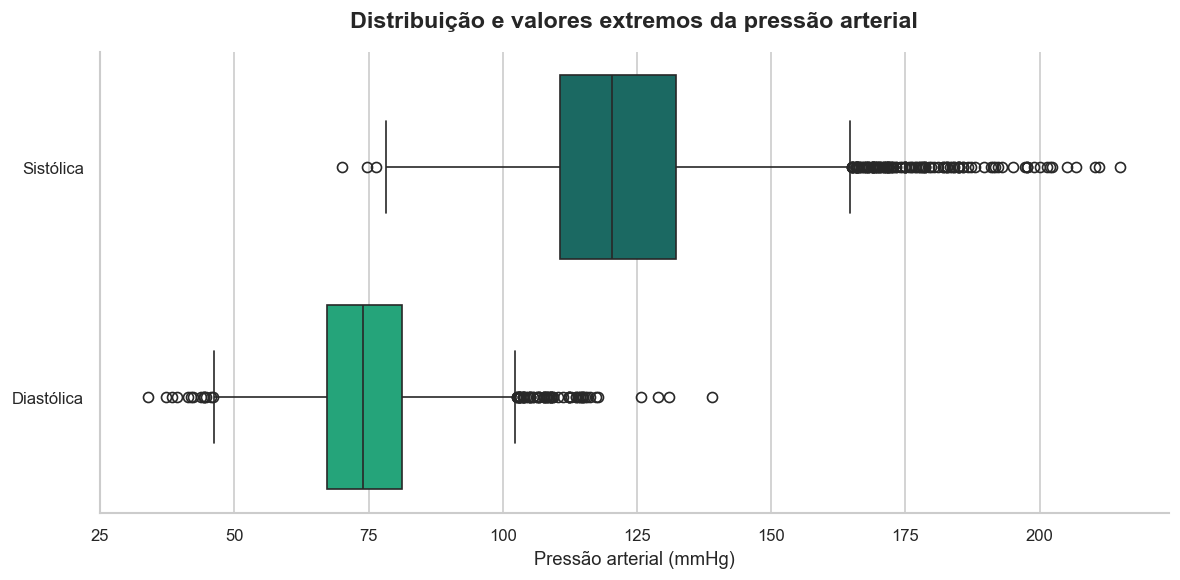

In [10]:
pressao_long = (
    df[
        [
            "pressao_sistolica",
            "pressao_diastolica"
        ]
    ]
    .rename(
        columns={
            "pressao_sistolica": "Sistólica",
            "pressao_diastolica": "Diastólica"
        }
    )
    .melt(
        var_name="Tipo de pressão",
        value_name="Pressão (mmHg)"
    )
)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=pressao_long,
    y="Tipo de pressão",
    x="Pressão (mmHg)",
    hue="Tipo de pressão",
    palette={
        "Sistólica": COR_PRINCIPAL,
        "Diastólica": COR_SECUNDARIA
    },
    legend=False
)

plt.title(
    "Distribuição e valores extremos da pressão arterial",
    pad=15,
    weight="bold"
)

plt.xlabel("Pressão arterial (mmHg)")
plt.ylabel("")

sns.despine()

plt.tight_layout()
plt.show()

O boxplot evidencia maior amplitude da pressão sistólica em comparação com a diastólica e mostra a presença de observações afastadas das regiões centrais em ambas as medidas.

Esses valores justificam uma inspeção individual das extremidades da distribuição. Entretanto, o objetivo dessa inspeção é verificar a consistência dos registros, e não remover automaticamente participantes com medidas elevadas ou reduzidas.

### 6.5 Inspeção dos valores extremos

Após a identificação visual de valores extremos, são inspecionados os participantes com maiores valores de pressão sistólica e diastólica e aqueles com menores valores de pressão sistólica.

Além das próprias medidas de pressão, são apresentadas características como idade, sexo, IMC e histórico informado de hipertensão para fornecer contexto aos registros observados.

Essa inspeção possui caráter exploratório e não tem como objetivo determinar individualmente a condição clínica dos participantes.

In [11]:
maiores_sistolica = (
    df[
        [
            "id_participante",
            "idade",
            "sexo",
            "imc",
            "pressao_sistolica",
            "pressao_diastolica",
            "hipertensao_informada"
        ]
    ]
    .sort_values(
        "pressao_sistolica",
        ascending=False
    )
    .head(20)
)

display(maiores_sistolica)

,id_participante,idade,sexo,imc,pressao_sistolica,pressao_diastolica,hipertensao_informada
2274,135571.0,65.0,Homem,29.5,215.0,117.7,0.0
3141,137481.0,58.0,Homem,26.0,211.0,74.3,1.0
1657,134148.0,80.0,Mulher,17.0,210.3,94.7,1.0
287,131005.0,64.0,Homem,30.1,206.7,115.3,1.0
2844,136864.0,72.0,Mulher,30.2,205.0,109.3,1.0
2277,135582.0,77.0,Mulher,31.6,202.3,80.3,1.0
5125,141921.0,64.0,Mulher,27.0,202.0,114.7,1.0
1777,134411.0,74.0,Homem,17.7,201.3,85.0,1.0
5229,142186.0,68.0,Homem,23.6,200.0,98.7,0.0
1260,133188.0,80.0,Mulher,31.1,199.0,83.3,1.0


In [12]:
maiores_diastolica = (
    df[
        [
            "id_participante",
            "idade",
            "sexo",
            "imc",
            "pressao_sistolica",
            "pressao_diastolica",
            "hipertensao_informada"
        ]
    ]
    .sort_values(
        "pressao_diastolica",
        ascending=False
    )
    .head(20)
)

display(maiores_diastolica)

,id_participante,idade,sexo,imc,pressao_sistolica,pressao_diastolica,hipertensao_informada
1410,133541.0,46.0,Mulher,36.6,185.0,139.0,1.0
368,131194.0,49.0,Homem,28.6,166.3,131.0,1.0
4944,141496.0,41.0,Mulher,43.7,186.7,129.0,1.0
2972,137142.0,71.0,Homem,23.5,197.7,125.7,1.0
2274,135571.0,65.0,Homem,29.5,215.0,117.7,0.0
428,131327.0,63.0,Mulher,59.9,159.3,117.3,1.0
3289,137815.0,48.0,Mulher,37.4,158.0,116.3,1.0
5235,142203.0,59.0,Homem,21.8,191.7,115.7,1.0
287,131005.0,64.0,Homem,30.1,206.7,115.3,1.0
2606,136328.0,43.0,Homem,40.8,171.7,115.0,1.0


In [13]:
menores_pressao = (
    df[
        [
            "id_participante",
            "idade",
            "sexo",
            "pressao_sistolica",
            "pressao_diastolica",
            "hipertensao_informada"
        ]
    ]
    .sort_values(
        "pressao_sistolica"
    )
    .head(20)
)

display(menores_pressao)

,id_participante,idade,sexo,pressao_sistolica,pressao_diastolica,hipertensao_informada
4582,140699.0,66.0,Homem,70.0,42.0,1.0
1383,133487.0,77.0,Homem,74.7,44.3,0.0
2170,135351.0,80.0,Homem,76.3,51.3,1.0
484,131457.0,73.0,Mulher,78.3,54.7,1.0
3210,137634.0,68.0,Homem,79.7,52.0,1.0
3359,137963.0,71.0,Homem,79.7,46.3,0.0
4827,141252.0,56.0,Homem,81.7,56.0,1.0
3530,138327.0,44.0,Homem,81.7,53.0,1.0
1513,133784.0,74.0,Mulher,82.0,50.7,0.0
4399,140328.0,75.0,Homem,82.0,51.3,1.0


A inspeção confirma a presença de participantes com medidas consideravelmente afastadas da região central da distribuição. A pressão sistólica atingiu **215 mmHg**, enquanto a maior pressão diastólica observada foi de **139 mmHg**. Na extremidade inferior, a menor pressão sistólica foi de **70 mmHg**.

Entre os participantes com valores elevados aparecem tanto indivíduos que informaram hipertensão quanto alguns que não informaram a condição. Da mesma forma, entre os menores valores de pressão existem participantes com diferentes históricos informados.

Essas combinações não serão interpretadas como confirmação, ausência ou erro de diagnóstico. O histórico informado e a medida obtida durante o exame representam informações distintas e serão comparados posteriormente de maneira específica.

Como não foram identificados, nesta inspeção, elementos suficientes para considerar essas observações erros de registro, os valores extremos foram preservados na base.

### 6.6 Relação entre pressão sistólica e diastólica

**Pergunta da análise:** existe associação linear entre os valores de pressão sistólica e diastólica na amostra?

Como as duas medidas pertencem ao mesmo conjunto de avaliação da pressão arterial, é relevante investigar como elas variam conjuntamente.

O gráfico de dispersão permite visualizar a relação entre as duas variáveis para cada participante, enquanto o coeficiente de correlação de Pearson resume a direção e a intensidade da associação linear observada.

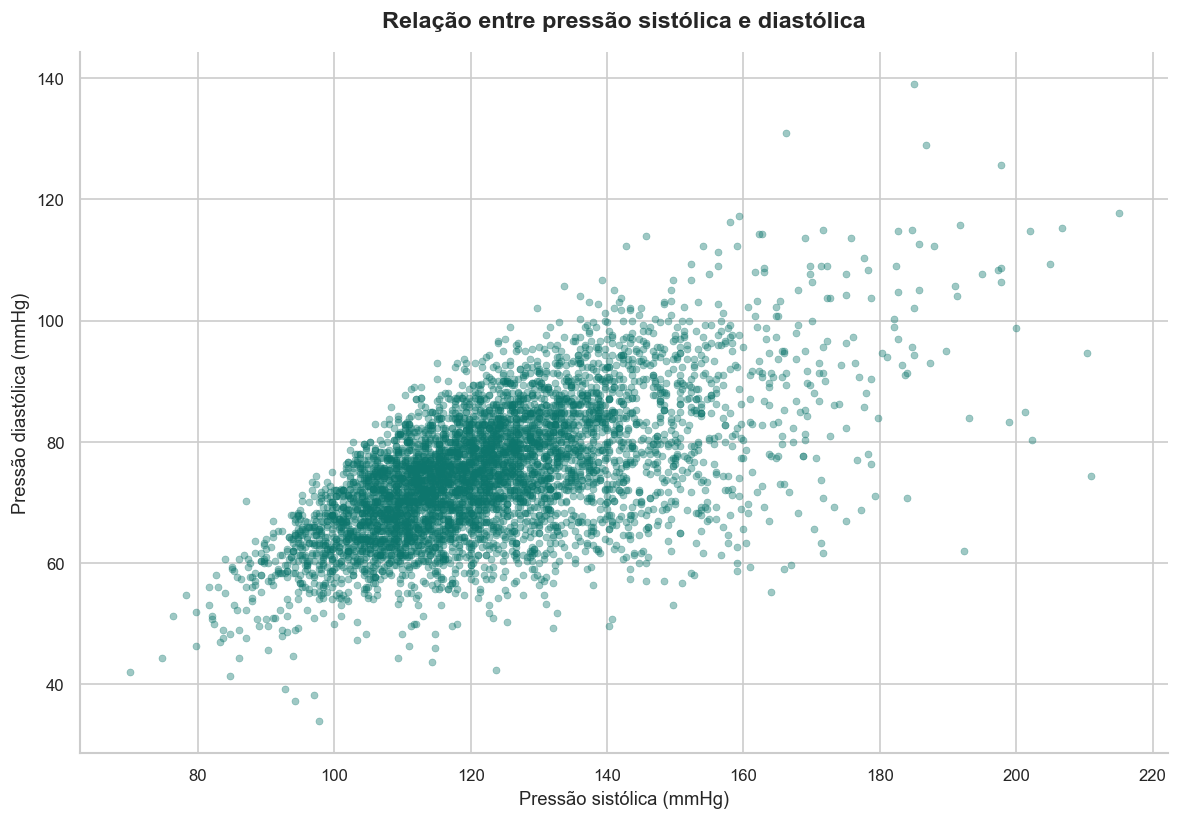

In [47]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="pressao_sistolica",
    y="pressao_diastolica",
    color=COR_PRINCIPAL,
    alpha=0.40,
    s=18,
    edgecolor=None
)

plt.title(
    "Relação entre pressão sistólica e diastólica",
    pad=15,
    weight="bold"
)

plt.xlabel("Pressão sistólica (mmHg)")
plt.ylabel("Pressão diastólica (mmHg)")


sns.despine()

plt.tight_layout()
plt.show()

*Cada ponto representa um participante da amostra.*

In [25]:
correlacao_pressao = (
    df[
        [
            "pressao_sistolica",
            "pressao_diastolica"
        ]
    ]
    .corr()
)

display(
    correlacao_pressao.round(3)
)

,pressao_sistolica,pressao_diastolica
pressao_sistolica,1.000,0.612
pressao_diastolica,0.612,1.000


A pressão sistólica e a pressão diastólica apresentaram correlação de Pearson de **0,612**, indicando uma associação linear positiva entre as duas medidas na amostra.

De modo geral, participantes com valores mais elevados de pressão sistólica também tendem a apresentar valores mais elevados de pressão diastólica. Entretanto, a dispersão dos pontos mostra que essa relação não é perfeita e que existem diferenças consideráveis entre os participantes.

A correlação descreve uma associação entre as duas medidas e não deve ser interpretada como evidência de que uma delas cause alterações na outra.

### 6.7 Pressão arterial × hipertensão informada

**Pergunta da análise:** participantes que informaram histórico de hipertensão apresentam distribuições diferentes de pressão arterial no momento do exame?

Primeiramente, é verificada a distribuição da variável de hipertensão informada. Em seguida, são comparadas as médias e medianas da pressão sistólica e diastólica entre os participantes que informaram e não informaram a condição.

O objetivo é investigar uma associação descritiva entre histórico informado e medidas atuais, sem utilizar essas informações para confirmar ou descartar diagnósticos individuais.

In [26]:
distribuicao_hipertensao = (
    df["hipertensao_informada"]
    .value_counts(dropna=False)
    .rename_axis("Hipertensão informada")
    .reset_index(name="Quantidade")
)

display(distribuicao_hipertensao)

,Hipertensão informada,Quantidade
0,0.0,3304
1,1.0,1976
2,NaN,3


Dos participantes com resposta disponível, **3.304 não informaram hipertensão** e **1.976 informaram a condição**. Apenas três registros não possuem informação disponível nessa variável.

In [27]:
resumo_pressao_hipertensao = (
    df
    .groupby(
        "hipertensao_informada",
        observed=True
    )
    .agg(
        participantes=(
            "id_participante",
            "count"
        ),
        sistolica_media=(
            "pressao_sistolica",
            "mean"
        ),
        sistolica_mediana=(
            "pressao_sistolica",
            "median"
        ),
        diastolica_media=(
            "pressao_diastolica",
            "mean"
        ),
        diastolica_mediana=(
            "pressao_diastolica",
            "median"
        )
    )
    .round(2)
)

display(resumo_pressao_hipertensao)

,participantes,sistolica_media,sistolica_mediana,diastolica_media,diastolica_mediana
hipertensao_informada,,,,,
0.0,3304,118.27,116.3,73.64,73.3
1.0,1976,130.02,128.0,76.59,75.7


Os participantes que informaram hipertensão apresentaram valores mais elevados de pressão arterial no momento do exame.

Nesse grupo, a pressão sistólica apresentou média de **130,02 mmHg** e mediana de **128,0 mmHg**, enquanto entre os participantes que não informaram hipertensão a média foi de **118,27 mmHg** e a mediana de **116,3 mmHg**.

Para a pressão diastólica, as médias foram de **76,59 mmHg** entre aqueles que informaram hipertensão e **73,64 mmHg** entre aqueles que não informaram. As medianas foram, respectivamente, **75,7 e 73,3 mmHg**.

As diferenças foram mais evidentes para a pressão sistólica. Entretanto, essas estatísticas resumem os grupos e não mostram toda a variabilidade existente entre seus participantes, que será examinada visualmente a seguir.

### 6.8 Comparação visual segundo hipertensão informada

Os gráficos de violino complementam as estatísticas anteriores ao mostrar a distribuição completa das medidas nos dois grupos.

A largura de cada região do gráfico representa a concentração relativa de observações, enquanto as linhas internas indicam a mediana e os quartis. Dessa forma, é possível avaliar não apenas diferenças nos valores centrais, mas também a dispersão e a sobreposição entre os grupos.

In [41]:
df["hipertensao_label"] = (
    df["hipertensao_informada"]
    .map({
        0.0: "Não",
        1.0: "Sim"
    })
)

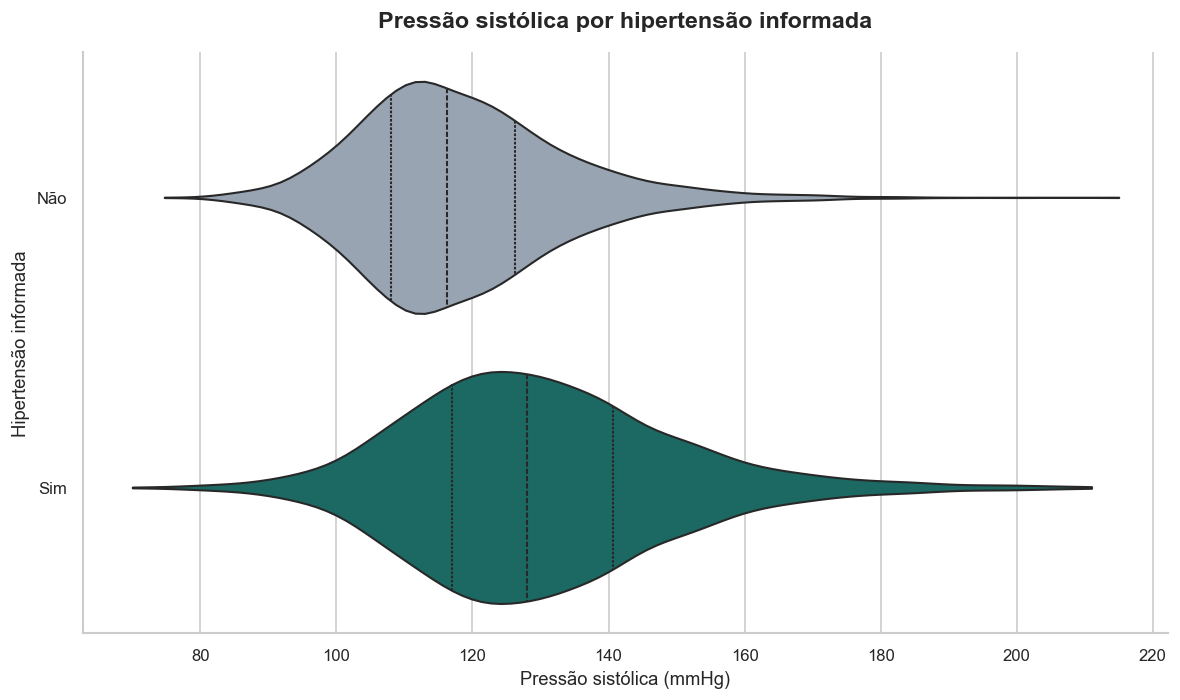

In [42]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    y="hipertensao_label",
    x="pressao_sistolica",
    order=["Não", "Sim"],
    hue="hipertensao_label",
    palette={
        "Não": COR_NEUTRA,
        "Sim": COR_PRINCIPAL
    },
    inner="quartile",
    cut=0,
    legend=False
)

plt.title(
    "Pressão sistólica por hipertensão informada",
    pad=15,
    weight="bold"
)

plt.xlabel("Pressão sistólica (mmHg)")
plt.ylabel("Hipertensão informada")

sns.despine()

plt.tight_layout()
plt.show()

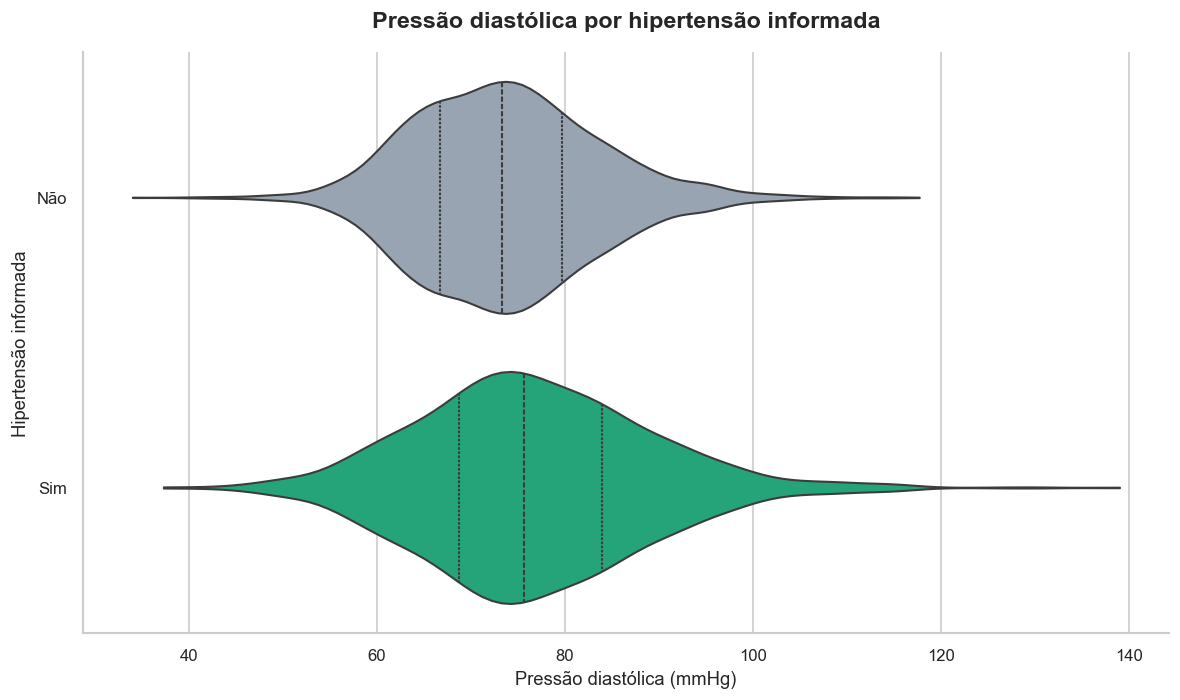

In [43]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    y="hipertensao_label",
    x="pressao_diastolica",
    order=["Não", "Sim"],
    hue="hipertensao_label",
    palette={
        "Não": COR_NEUTRA,
        "Sim": COR_SECUNDARIA
    },
    inner="quartile",
    cut=0,
    legend=False
)

plt.title(
    "Pressão diastólica por hipertensão informada",
    pad=15,
    weight="bold"
)

plt.xlabel("Pressão diastólica (mmHg)")
plt.ylabel("Hipertensão informada")

sns.despine()

plt.tight_layout()
plt.show()

As distribuições confirmam a diferença observada nas estatísticas descritivas, principalmente para a pressão sistólica. O grupo que informou hipertensão apresenta distribuição deslocada para valores sistólicos mais elevados.

Entretanto, existe sobreposição considerável entre os grupos tanto para a pressão sistólica quanto para a diastólica. Isso significa que o valor da pressão observado no exame, isoladamente, não reproduz perfeitamente o histórico informado pelos participantes.

Essa sobreposição é esperada em uma comparação entre histórico e medida atual, pois as informações representam momentos e aspectos diferentes da condição de saúde.

### 6.9 Idade × pressão arterial

**Pergunta da análise:** existe associação entre idade e pressão sistólica entre os participantes da amostra?

A relação é analisada por meio de um gráfico de dispersão, no qual cada ponto representa um participante, e pelo coeficiente de correlação de Pearson.

Como os dados são transversais, participantes de diferentes idades representam indivíduos distintos. Portanto, a análise permite investigar diferenças associadas à idade na amostra, mas não representa a evolução da pressão arterial dos mesmos indivíduos durante o envelhecimento.

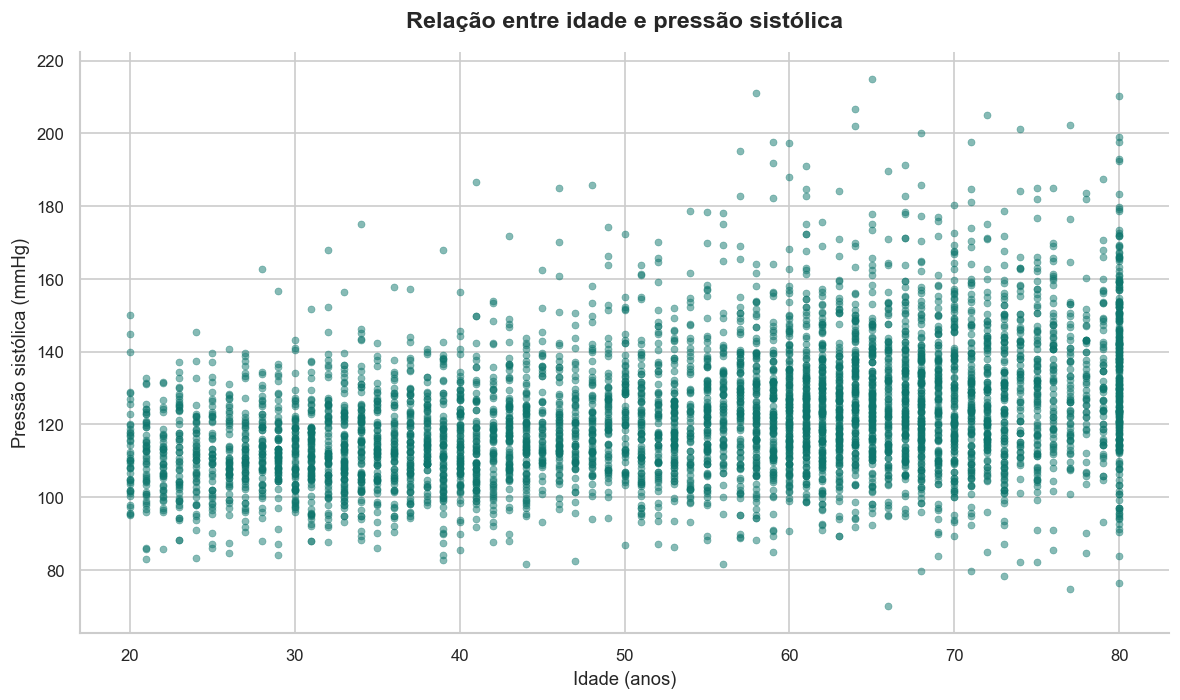

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="idade",
    y="pressao_sistolica",
    color=COR_PRINCIPAL,
    alpha=0.50,
    s=18,
    edgecolor=None
)

plt.title(
    "Relação entre idade e pressão sistólica",
    pad=15,
    weight="bold"
)

plt.xlabel("Idade (anos)")
plt.ylabel("Pressão sistólica (mmHg)")

sns.despine()

plt.tight_layout()
plt.show()

In [48]:
corr_idade_sistolica = (
    df[
        [
            "idade",
            "pressao_sistolica"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Correlação idade × pressão sistólica: "
    f"{corr_idade_sistolica:.3f}"
)

Correlação idade × pressão sistólica: 0.377


A idade e a pressão sistólica apresentaram correlação de Pearson de **0,377**, indicando uma associação linear positiva na amostra.

Observa-se uma tendência de participantes com maior idade apresentarem valores sistólicos mais elevados, embora exista ampla dispersão das medidas em praticamente todas as idades.

O coeficiente não implica que a idade, isoladamente, determine a pressão sistólica e não permite estabelecer relação causal. Além disso, por se tratar de uma análise transversal, o resultado não representa a trajetória individual da pressão arterial durante o envelhecimento.

### 6.10 Síntese do perfil pressórico

A análise mostrou que a pressão sistólica apresentou maior dispersão que a pressão diastólica e que a grande maioria dos participantes possui três leituras válidas utilizadas no cálculo das medidas médias.

Foram identificados valores afastados das regiões centrais das distribuições, tanto superiores quanto inferiores. Esses registros foram preservados, pois a inspeção exploratória não forneceu evidências suficientes para classificá-los automaticamente como erros.

A pressão sistólica e a diastólica apresentaram associação linear positiva entre si. Também foram observadas diferenças nas medidas segundo o histórico informado de hipertensão, principalmente para a pressão sistólica, embora exista sobreposição entre os grupos.

A idade apresentou associação positiva com a pressão sistólica na amostra, mas essa relação deve ser interpretada no contexto transversal dos dados e não como acompanhamento do envelhecimento dos participantes.

Em conjunto, os resultados caracterizam o perfil pressórico da amostra e reforçam a necessidade de distinguir **medidas atuais de pressão arterial** de **histórico informado de hipertensão**, especialmente na futura definição das variáveis utilizadas nos modelos de Machine Learning.

Ademais, a análise da pressão arterial está diretamente relacionada às funcionalidades previstas para o HealthSync, uma vez que a pressão sistólica e a pressão diastólica estão entre os indicadores que poderão ser registrados e acompanhados pelo usuário.